# **Data Cleaning and Pre-processing**

In [ ]:
import os
import pandas as pd
import numpy as np

def clean_csv_files(input_folder, output_folder, project_status_file):
    os.makedirs(output_folder, exist_ok=True)

    ps_df = pd.read_csv(project_status_file, keep_default_na=False, na_values=[], low_memory=False)

    columns_to_drop = [
        'issue_url', 'comment_url', 'id', 'issue_num',
        'title', 'user_login', 'user_id', 'user_name',
        'user_email', 'body', 'reactions'
    ]

    for filename in os.listdir(input_folder):
        if filename.endswith(".csv"):
            file_path = os.path.join(input_folder, filename)

            df = pd.read_csv(file_path, keep_default_na=False, na_values=[], low_memory=False)

            df = df.drop(columns=[col for col in columns_to_drop if col in df.columns], errors='ignore')

            if 'created_at' in df.columns:
                df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce').dt.date
            if 'updated_at' in df.columns:
                df['updated_at'] = pd.to_datetime(df['updated_at'], errors='coerce').dt.date

            if 'created_at' in df.columns and 'updated_at' in df.columns:
                df['days_elapsed'] = (df['updated_at'] - df['created_at']).apply(
                    lambda x: x.days + 1 if pd.notnull(x) else np.nan
                )

            df = df.replace(r'^\s*$', np.nan, regex=True)

            for col in df.columns:
                if pd.api.types.is_numeric_dtype(df[col]):
                    df[col] = df[col].fillna(0)
                else:
                    df[col] = df[col].fillna(np.nan)

            if 'repo_name' in df.columns:
                df = df.merge(ps_df[['project', 'status']], how='left', left_on='repo_name', right_on='project')
                df = df.drop(columns=['project'])

            output_file = os.path.join(output_folder, filename)
            df.to_csv(output_file, index=False)

input_folder = "issues-output"
output_folder = "issues-cleanedData"
project_status_file = "project-status.csv"
clean_csv_files(input_folder, output_folder, project_status_file)


## **EDA Analysis on the Issues Data**

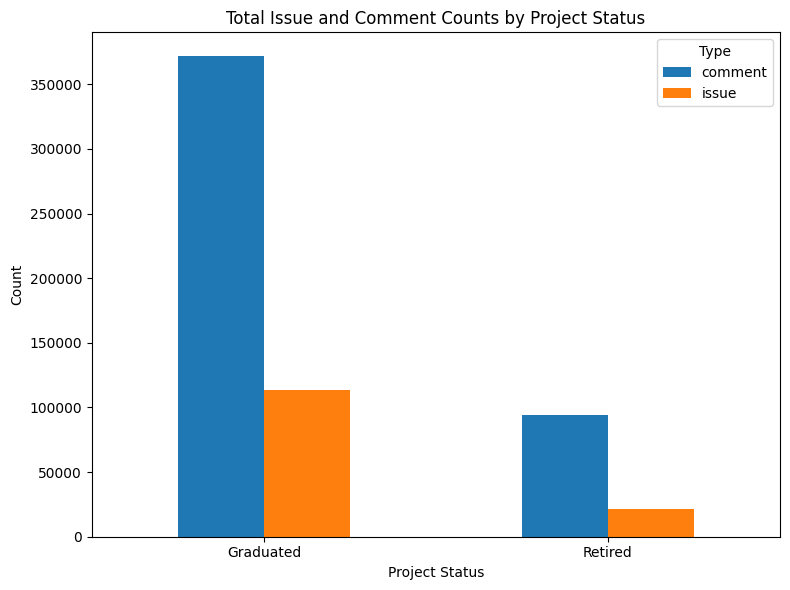

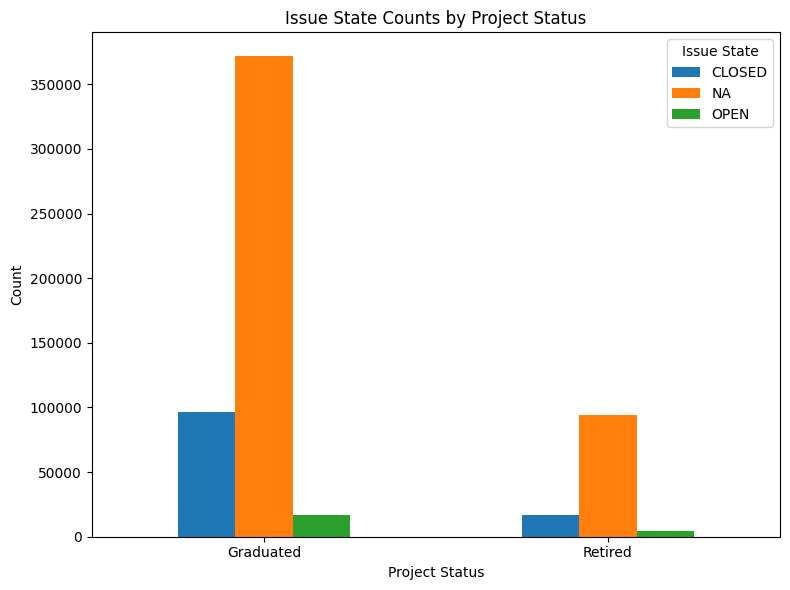

In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def load_cleaned_data(folder):
    """Load all CSV files from the given folder and concatenate them into one DataFrame."""
    all_dfs = []
    for filename in os.listdir(folder):
        if filename.endswith(".csv"):
            file_path = os.path.join(folder, filename)
            df = pd.read_csv(file_path)
            all_dfs.append(df)
    if all_dfs:
        return pd.concat(all_dfs, ignore_index=True)
    else:
        return pd.DataFrame()

cleaned_folder = "issues-cleanedData"
df = load_cleaned_data(cleaned_folder)


# Plot 1: Count of Issues and Comments by Status

if "status" in df.columns and "type" in df.columns:
    # Group by status and type
    grouped_type = df.groupby(["status", "type"]).size().reset_index(name="count")
    pivot_type = grouped_type.pivot(index="status", columns="type", values="count").fillna(0)

    plt.figure(figsize=(8,6))
    pivot_type.plot(kind="bar", ax=plt.gca())
    plt.title("Total Issue and Comment Counts by Project Status")
    plt.xlabel("Project Status")
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.legend(title="Type")
    plt.tight_layout()
    plt.show()
else:
    print("Columns 'status' and/or 'type' not found in the data for Plot 1.")

# Plot 2: Issue State Counts (Open, Closed, NA) by Status

if "status" in df.columns and "issue_state" in df.columns:
    df["issue_state_group"] = df["issue_state"].fillna("NA")
    grouped_state = df.groupby(["status", "issue_state_group"]).size().reset_index(name="count")
    pivot_state = grouped_state.pivot(index="status", columns="issue_state_group", values="count").fillna(0)

    plt.figure(figsize=(8,6))
    pivot_state.plot(kind="bar", ax=plt.gca())
    plt.title("Issue State Counts by Project Status")
    plt.xlabel("Project Status")
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.legend(title="Issue State")
    plt.tight_layout()
    plt.show()
else:
    print("Columns 'status' and/or 'issue_state' not found in the data for Plot 2.")


# **p-value Analysis**

# **For Plot 1 (Issue and Comment Counts by Project Status):**
**Null Hypothesis (H₀):** There is no association between project status and the type (issue or comment); in other words, the distribution of issue and comment counts is independent of the project status.
**Alternative Hypothesis (H₁):** There is an association between project status and the type; that is, the distribution of counts differs by project status.
# **For Plot 2 (Issue State Counts by Project Status):**
**Null Hypothesis (H₀):** There is no association between project status and issue state (open, closed, or NA); meaning the distribution of issue states is independent of the project status.
**Alternative Hypothesis (H₁):** There is an association between project status and issue state; the distribution of issue states varies depending on the project status.


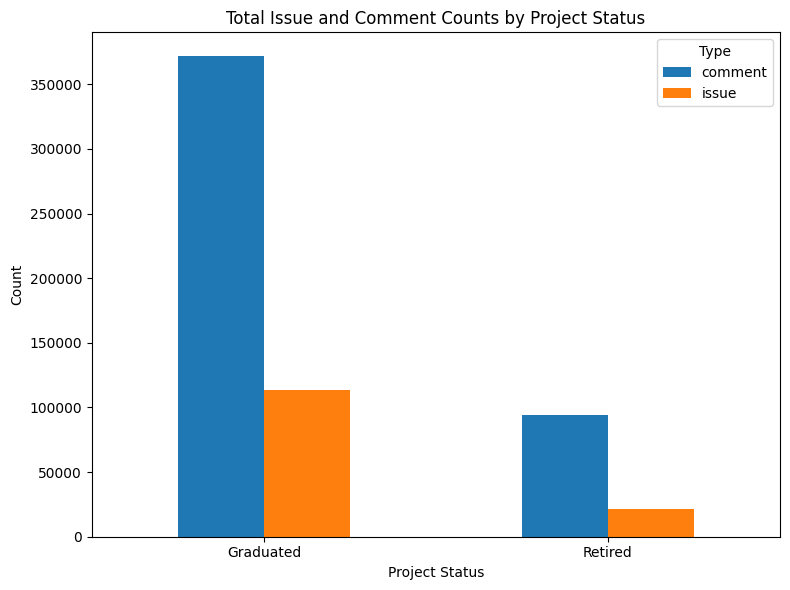

Chi-square test for issue and comment counts by project status:
Chi-square value: 1369.9316310834963
Degrees of freedom: 1
p-value: 7.18456023088511e-300


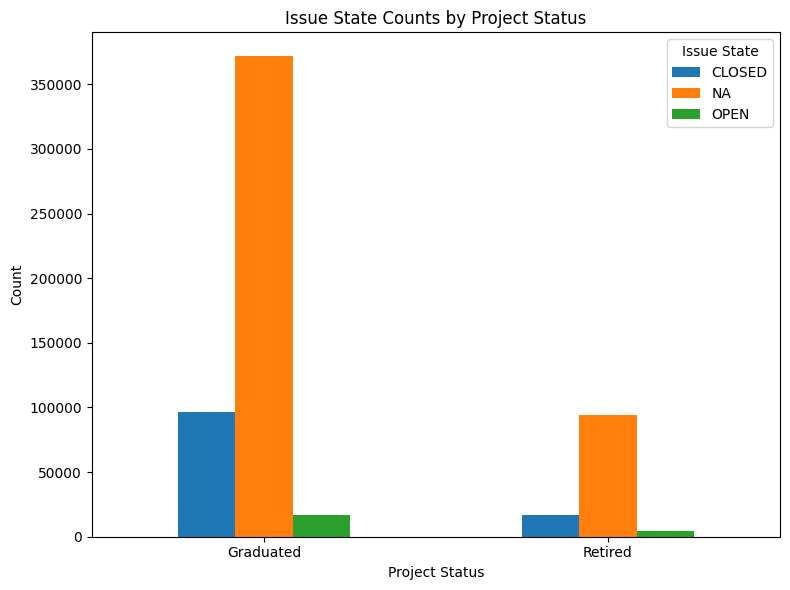


Chi-square test for issue state counts by project status:
Chi-square value: 1866.88455871706
Degrees of freedom: 2
p-value:  0.0


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2_contingency

def load_cleaned_data(folder):
    all_dfs = []
    for filename in os.listdir(folder):
        if filename.endswith(".csv"):
            file_path = os.path.join(folder, filename)
            df = pd.read_csv(file_path)
            all_dfs.append(df)
    if all_dfs:
        return pd.concat(all_dfs, ignore_index=True)
    else:
        return pd.DataFrame()

# Load data from the folder "issues-cleanedData"
cleaned_folder = "issues-cleanedData"
df = load_cleaned_data(cleaned_folder)

# --- Plot 1: Count of Issues and Comments by Status ---
if "status" in df.columns and "type" in df.columns:
    grouped_type = df.groupby(["status", "type"]).size().reset_index(name="count")
    pivot_type = grouped_type.pivot(index="status", columns="type", values="count").fillna(0)

    plt.figure(figsize=(8,6))
    pivot_type.plot(kind="bar", ax=plt.gca())
    plt.title("Total Issue and Comment Counts by Project Status")
    plt.xlabel("Project Status")
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.legend(title="Type")
    plt.tight_layout()
    plt.show()

    # Perform chi-square test on the pivot table data
    contingency_table_type = pivot_type.values
    chi2, p_value, dof, expected = chi2_contingency(contingency_table_type)
    print("Chi-square test for issue and comment counts by project status:")
    print("Chi-square value:", chi2)
    print("Degrees of freedom:", dof)
    print("p-value:", p_value)
else:
    print("Columns 'status' and/or 'type' not found in the data for Plot 1.")

# --- Plot 2: Issue State Counts (Open, Closed, NA) by Status ---
if "status" in df.columns and "issue_state" in df.columns:
    df["issue_state_group"] = df["issue_state"].fillna("NA")
    grouped_state = df.groupby(["status", "issue_state_group"]).size().reset_index(name="count")
    pivot_state = grouped_state.pivot(index="status", columns="issue_state_group", values="count").fillna(0)

    plt.figure(figsize=(8,6))
    pivot_state.plot(kind="bar", ax=plt.gca())
    plt.title("Issue State Counts by Project Status")
    plt.xlabel("Project Status")
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.legend(title="Issue State")
    plt.tight_layout()
    plt.show()

    # Perform chi-square test on the pivot table data for issue state
    contingency_table_state = pivot_state.values
    chi2_state, p_value_state, dof_state, expected_state = chi2_contingency(contingency_table_state)
    print("\nChi-square test for issue state counts by project status:")
    print("Chi-square value:", chi2_state)
    print("Degrees of freedom:", dof_state)
    print("p-value: ", p_value_state)
else:
    print("Columns 'status' and/or 'issue_state' not found in the data for Plot 2.")


# **LSTM Model for Classifying projects as Graduated/ Retired based on Issues Data**

In [ ]:
import os
import sys
import pandas as pd
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Masking
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report


epochs = 10             
batch_size = 16          
learning_rate = 0.001   
weight_decay = 1e-4      

lstm_units_layer1 = 128  
lstm_units_layer2 = 64  
dropout_rate = 0.02      


input_dir = "issues-cleanedData" 

sequences = []
labels = []

issue_state_categories = set()
for filename in os.listdir(input_dir):
    if filename.endswith(".csv"):
        file_path = os.path.join(input_dir, filename)
        try:
            df = pd.read_csv(file_path)
        except Exception as e:
            print(f"Error reading {filename}: {e}")
            continue
        if 'type' in df.columns:
            df = df[df['type'] != 'comment']
        if 'issue_state' in df.columns:
            unique_states = df['issue_state'].dropna().unique()
            issue_state_categories.update(unique_states)
issue_state_categories = sorted(list(issue_state_categories))

label_map = {"graduated": 1, "retired": 0}

for filename in os.listdir(input_dir):
    if filename.endswith(".csv"):
        file_path = os.path.join(input_dir, filename)
        try:
            df = pd.read_csv(file_path)
        except Exception as e:
            print(f"Error reading {filename}: {e}")
            continue

        if 'type' in df.columns:
            df = df[df['type'] != 'comment']

        if not all(col in df.columns for col in ['issue_state', 'days_elapsed', 'status']):
            print(f"Skipping {filename}: required columns missing.")
            continue

        repo_status = df['status'].iloc[0]
        repo_status = repo_status.lower() if isinstance(repo_status, str) else repo_status
        if repo_status not in label_map:
            print(f"Skipping {filename}: status value '{repo_status}' not in label_map.")
            continue

        issue_state_dummies = pd.get_dummies(df['issue_state']).astype(int)
        issue_state_dummies = issue_state_dummies.reindex(columns=issue_state_categories, fill_value=0)

        try:
            days_elapsed = (df['days_elapsed'].astype(float).to_frame()) / 1000.0
        except Exception as e:
            print(f"Error processing 'days_elapsed' in {filename}: {e}")
            continue

        if 'comments_count' in df.columns:
            try:
                comments_count = (df['comments_count'].astype(float).to_frame()) / 100.0
            except Exception as e:
                print(f"Error processing 'comments_count' in {filename}: {e}")
                comments_count = pd.DataFrame(np.zeros((df.shape[0], 1)), columns=["comments_count"])
            features = pd.concat([issue_state_dummies, days_elapsed, comments_count], axis=1)
        else:
            features = pd.concat([issue_state_dummies, days_elapsed], axis=1)

        features = features.fillna(0)

        seq = features.values
        if seq.shape[0] == 0:
            print(f"Skipping {filename}: no valid rows after filtering.")
            continue

        sequences.append(seq)
        labels.append(label_map[repo_status])

if not sequences:
    sys.exit("Error: No valid sequences found. Check CSV files for required columns and valid status values.")

max_timesteps = max(seq.shape[0] for seq in sequences)
X = pad_sequences(sequences, maxlen=max_timesteps, dtype='float32', padding='post', value=-999.0)
y = np.array(labels)

print("Processed Data Summary:")
print("Number of sequences:", len(sequences))
print("Shape of padded sequences (X):", X.shape)
print("Labels (y):", y)


X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42, shuffle=True
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=2/3, stratify=y_temp, random_state=42, shuffle=True
)

print("Train shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)


num_features = X.shape[2] 

model = Sequential()
model.add(Masking(mask_value=-999.0, input_shape=(max_timesteps, num_features)))

# First LSTM layer with 128 units, dropout and recurrent dropout, returning sequences (for stacking)
model.add(LSTM(lstm_units_layer1,
               dropout=dropout_rate,
               return_sequences=True,
               kernel_regularizer=l2(weight_decay)))

# Second LSTM layer with 64 units, dropout and recurrent dropout (outputs final hidden state)
model.add(LSTM(lstm_units_layer2,
               dropout=dropout_rate,
               kernel_regularizer=l2(weight_decay)))

# Final Dense layer for binary classification (graduated vs. retired)
model.add(Dense(1, activation='relu', kernel_regularizer=l2(weight_decay)))

optimizer = Adam(learning_rate=learning_rate)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_val, y_val))


y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).reshape(-1)

cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred)

test_accuracy = np.mean(y_pred == y_test)
print("Test Accuracy:", test_accuracy)

print("Confusion Matrix:")
print(cm)
print("\nClassification Report:")
print(cr)


Processed Data Summary:
Number of sequences: 88
Shape of padded sequences (X): (88, 15520, 3)
Labels (y): [0 1 1 1 0 1 1 0 1 1 0 1 0 1 0 0 0 1 0 1 1 1 0 0 1 1 0 1 1 1 1 1 1 1 0 1 1
 1 1 0 1 1 1 0 1 1 1 1 1 1 0 1 0 0 1 1 0 1 1 0 1 0 1 0 1 1 1 0 0 1 1 1 0 1
 0 1 1 1 1 1 1 1 0 0 0 0 1 1]
Train shape: (61, 15520, 3) (61,)
Validation shape: (9, 15520, 3) (9,)
Test shape: (18, 15520, 3) (18,)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/masking.py:47: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ masking_1 (Masking)                  │ (None, 15520, 3)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 15520, 128)          │          67,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 117,057 (457.25 KB)

 Trainable params: 117,057 (457.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 156s 35s/step - accuracy: 0.3148 - loss: 11.0621 - val_accuracy: 0.3333 - val_loss: 10.7621
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 186s 34s/step - accuracy: 0.3231 - loss: 10.9264 - val_accuracy: 0.3333 - val_loss: 10.7606
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 143s 36s/step - accuracy: 0.3460 - loss: 10.5555 - val_accuracy: 0.3333 - val_loss: 10.7592
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 221s 40s/step - accuracy: 0.3273 - loss: 10.8564 - val_accuracy: 0.3333 - val_loss: 10.7579
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 184s 36s/step - accuracy: 0.3273 - loss: 10.8552 - val_accuracy: 0.3333 - val_loss: 10.7568
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 194s 34s/step - accuracy: 0.3190 - loss: 10.9883 - val_accuracy: 0.3333 - val_loss: 10.7557
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 144s 35s/step - accuracy: 0.3752 - loss: 10.0806 - val_accuracy: 0.3333 - val_loss: 10.7547
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 139s 34s/step - accuracy: 0.3523 - loss: 10.4490 - val_accuracy: 0.3

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.6/383.6 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.8/231.8 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 6.7 MB/s eta 0:00:00


# Improved LSTM model

[I 2025-03-14 17:08:33,810] A new study created in memory with name: no-name-c927244d-67fb-4c04-b959-095bcb3006a5


Processed Data Summary:
Number of sequences: 88
Shape of padded sequences (X): (88, 27260, 3)
Labels (y): [0 1 1 1 0 0 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0 0 0 1 0 0 1 0 1 0 1 0 1 1 1 1
 1 1 1 0 1 0 1 1 1 1 0 1 1 1 1 1 1 1 0 1 0 0 1 1 1 0 1 1 0 1 1 1 1 0 1 1 1
 0 1 0 0 0 0 1 1 1 1 0 1 1 0]


  0%|          | 0/20 [00:00<?, ?it/s]

/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_73659/932603365.py:134: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("learning_rate", 1e-5, 1e-2)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_73659/932603365.py:135: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dr = trial.suggest_uniform("dropout_rate", 0.1, 0.5)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_73659/932603365.py:137: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  wd = trial.suggest_loguniform("weigh

Epoch 1/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.3607 - loss: 0.6940 - val_accuracy: 0.3333 - val_loss: 0.6937
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.3443 - loss: 0.6953 - val_accuracy: 0.3333 - val_loss: 0.6937
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.3607 - loss: 0.6940 - val_accuracy: 0.3333 - val_loss: 0.6938
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.3607 - loss: 0.6940 - val_accuracy: 0.3333 - val_loss: 0.6938
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.3607 - loss: 0.6940 - val_accuracy: 0.3333 - val_loss: 0.6939
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.3607 - loss: 0.6940 - val_accuracy: 0.3333 - val_loss: 0.6940
Epoch 7/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.3443 - loss: 0.6953 - val_accuracy: 0.3333 - val_loss: 0.6940
Epoch 8/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.3607 - loss: 0.6940 - val_accuracy: 0.3333 - val_loss: 0.6941
Epoch 9/15
1/1 ━

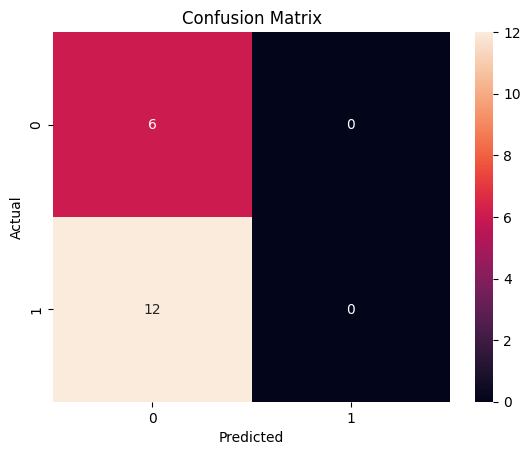

[I 2025-03-14 17:09:26,791] Trial 0 finished with value: 0.6944686770439148 and parameters: {'learning_rate': 4.7978118970541745e-05, 'dropout_rate': 0.12328006341530783, 'batch_size': 64, 'weight_decay': 6.201347720899703e-05, 'lstm_units': 32}. Best is trial 0 with value: 0.6944686770439148.


/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_73659/932603365.py:134: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("learning_rate", 1e-5, 1e-2)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_73659/932603365.py:135: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dr = trial.suggest_uniform("dropout_rate", 0.1, 0.5)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_73659/932603365.py:137: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  wd = trial.suggest_loguniform("weigh

Epoch 1/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 4s/step - accuracy: 0.3654 - loss: 0.6944 - val_accuracy: 0.3333 - val_loss: 0.6941
Epoch 2/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 3s/step - accuracy: 0.3654 - loss: 0.6942 - val_accuracy: 0.3333 - val_loss: 0.6949
Epoch 3/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 3s/step - accuracy: 0.3654 - loss: 0.6940 - val_accuracy: 0.3333 - val_loss: 0.6956
Epoch 4/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 3s/step - accuracy: 0.3441 - loss: 0.6949 - val_accuracy: 0.3333 - val_loss: 0.6962
Epoch 5/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 3s/step - accuracy: 0.3654 - loss: 0.6938 - val_accuracy: 0.3333 - val_loss: 0.6967
Epoch 6/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 5s/step - accuracy: 0.3441 - loss: 0.6949 - val_accuracy: 0.3333 - val_loss: 0.6969
Epoch 7/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 4s/step - accuracy: 0.3441 - loss: 0.6949 - val_accuracy: 0.3333 - val_loss: 0.6970
Epoch 8/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 4s/step - accuracy: 0.3441 - loss: 0.6949 - val_accuracy: 0.3333 - val_loss: 0.6968
Epoch 9/15
2/2 ━

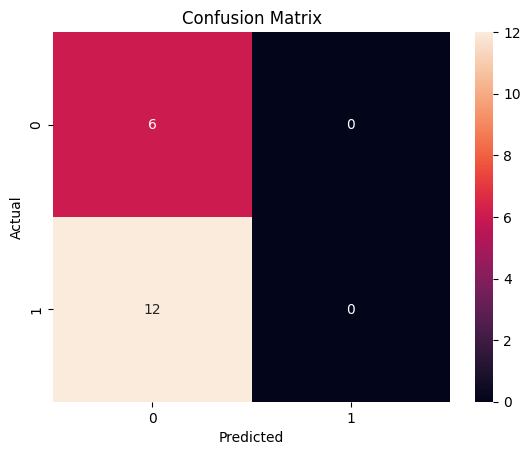

[I 2025-03-14 17:11:13,491] Trial 1 finished with value: 0.6958116292953491 and parameters: {'learning_rate': 0.00022733990296947774, 'dropout_rate': 0.42922206662698115, 'batch_size': 32, 'weight_decay': 2.684281913118668e-05, 'lstm_units': 64}. Best is trial 0 with value: 0.6944686770439148.


/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_73659/932603365.py:134: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("learning_rate", 1e-5, 1e-2)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_73659/932603365.py:135: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dr = trial.suggest_uniform("dropout_rate", 0.1, 0.5)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_73659/932603365.py:137: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  wd = trial.suggest_loguniform("weigh

Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.3773 - loss: 0.7111 - val_accuracy: 0.3333 - val_loss: 0.6933
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.3943 - loss: 0.7105 - val_accuracy: 0.3333 - val_loss: 0.6933
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.3943 - loss: 0.7105 - val_accuracy: 0.3333 - val_loss: 0.6933
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.3943 - loss: 0.7105 - val_accuracy: 0.3333 - val_loss: 0.6933
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.3773 - loss: 0.7111 - val_accuracy: 0.3333 - val_loss: 0.6933
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.3943 - loss: 0.7105 - val_accuracy: 0.3333 - val_loss: 0.6933
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.3943 - loss: 0.7105 - val_accuracy: 0.3333 - val_loss: 0.6933
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.3943 - loss: 0.7104 - val_accuracy: 0.3333 - val_loss: 0.6933
Epoch 9/15
4/4

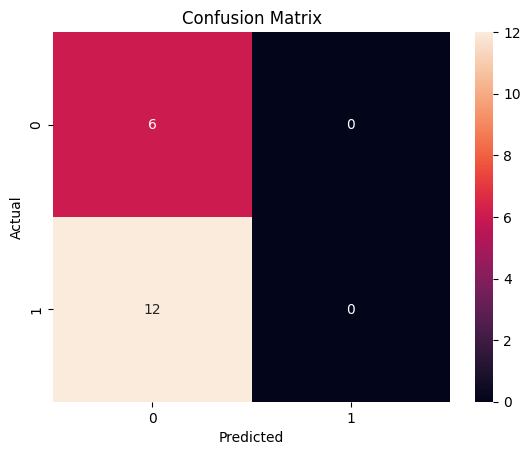

[I 2025-03-14 17:13:29,797] Trial 2 finished with value: 0.6932938098907471 and parameters: {'learning_rate': 1.3203437491576292e-05, 'dropout_rate': 0.11425257950848407, 'batch_size': 16, 'weight_decay': 1.07490863331669e-05, 'lstm_units': 64}. Best is trial 2 with value: 0.6932938098907471.


/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_73659/932603365.py:134: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("learning_rate", 1e-5, 1e-2)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_73659/932603365.py:135: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dr = trial.suggest_uniform("dropout_rate", 0.1, 0.5)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_73659/932603365.py:137: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  wd = trial.suggest_loguniform("weigh

Epoch 1/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 5s/step - accuracy: 0.3654 - loss: 0.6939 - val_accuracy: 0.3333 - val_loss: 0.6935
Epoch 2/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 4s/step - accuracy: 0.3654 - loss: 0.6938 - val_accuracy: 0.3333 - val_loss: 0.6937
Epoch 3/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 4s/step - accuracy: 0.3654 - loss: 0.6938 - val_accuracy: 0.3333 - val_loss: 0.6939
Epoch 4/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 3s/step - accuracy: 0.3654 - loss: 0.6938 - val_accuracy: 0.3333 - val_loss: 0.6941
Epoch 5/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 4s/step - accuracy: 0.3654 - loss: 0.6937 - val_accuracy: 0.3333 - val_loss: 0.6943
Epoch 6/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 5s/step - accuracy: 0.3654 - loss: 0.6937 - val_accuracy: 0.3333 - val_loss: 0.6945
Epoch 7/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 4s/step - accuracy: 0.3654 - loss: 0.6937 - val_accuracy: 0.3333 - val_loss: 0.6947
Epoch 8/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 4s/step - accuracy: 0.3441 - loss: 0.6948 - val_accuracy: 0.3333 - val_loss: 0.6949
Epoch 9/15
2/2 

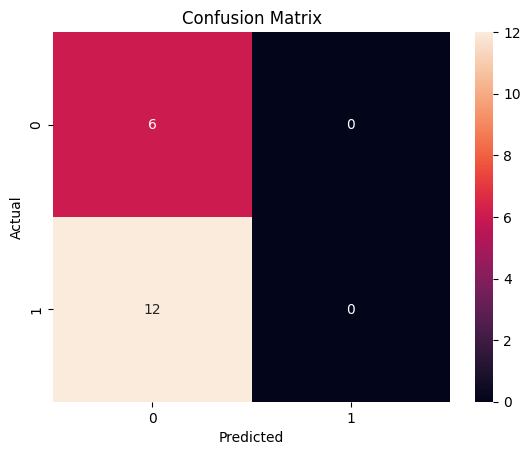

[I 2025-03-14 17:15:15,341] Trial 3 finished with value: 0.6959165334701538 and parameters: {'learning_rate': 5.709723876373661e-05, 'dropout_rate': 0.21779737818775288, 'batch_size': 32, 'weight_decay': 1.6960146804121756e-05, 'lstm_units': 64}. Best is trial 2 with value: 0.6932938098907471.


/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_73659/932603365.py:134: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("learning_rate", 1e-5, 1e-2)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_73659/932603365.py:135: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dr = trial.suggest_uniform("dropout_rate", 0.1, 0.5)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_73659/932603365.py:137: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  wd = trial.suggest_loguniform("weigh

Epoch 1/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step - accuracy: 0.3443 - loss: 0.6978 - val_accuracy: 0.3333 - val_loss: 0.6955
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.3443 - loss: 0.6963 - val_accuracy: 0.3333 - val_loss: 0.6964
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.3443 - loss: 0.6975 - val_accuracy: 0.3333 - val_loss: 0.6971
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.3443 - loss: 0.6963 - val_accuracy: 0.3333 - val_loss: 0.6977
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.3443 - loss: 0.6963 - val_accuracy: 0.3333 - val_loss: 0.6981
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.3443 - loss: 0.6971 - val_accuracy: 0.3333 - val_loss: 0.6983
Epoch 7/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.3443 - loss: 0.6963 - val_accuracy: 0.3333 - val_loss: 0.6983
Epoch 8/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.3443 - loss: 0.6969 - val_accuracy: 0.3333 - val_loss: 0.6982
Epoch 9/15
1/1

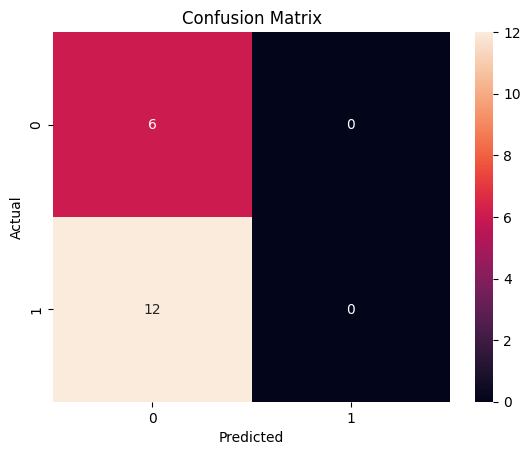

[I 2025-03-14 17:16:16,417] Trial 4 finished with value: 0.6965371966362 and parameters: {'learning_rate': 0.000583026539566974, 'dropout_rate': 0.46738311824277645, 'batch_size': 64, 'weight_decay': 0.00019534130114073347, 'lstm_units': 32}. Best is trial 2 with value: 0.6932938098907471.


/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_73659/932603365.py:134: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("learning_rate", 1e-5, 1e-2)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_73659/932603365.py:135: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dr = trial.suggest_uniform("dropout_rate", 0.1, 0.5)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_73659/932603365.py:137: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  wd = trial.suggest_loguniform("weigh

Epoch 1/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step - accuracy: 0.3607 - loss: 0.6953 - val_accuracy: 0.3333 - val_loss: 0.6940
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step - accuracy: 0.3607 - loss: 0.6952 - val_accuracy: 0.3333 - val_loss: 0.6942
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step - accuracy: 0.3607 - loss: 0.6952 - val_accuracy: 0.3333 - val_loss: 0.6945
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - accuracy: 0.3607 - loss: 0.6952 - val_accuracy: 0.3333 - val_loss: 0.6948
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - accuracy: 0.3607 - loss: 0.6951 - val_accuracy: 0.3333 - val_loss: 0.6951
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.3607 - loss: 0.6951 - val_accuracy: 0.3333 - val_loss: 0.6954
Epoch 7/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - accuracy: 0.3607 - loss: 0.6951 - val_accuracy: 0.3333 - val_loss: 0.6956
Epoch 8/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.3607 - loss: 0.6950 - val_accuracy: 0.3333 - val_loss: 0.6959
Epoch 9/15
1/1 ━

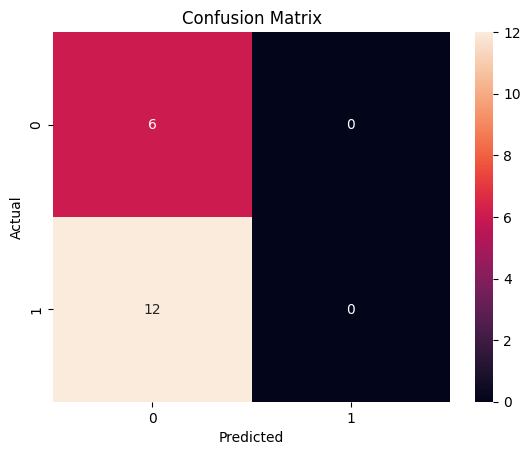

[I 2025-03-14 17:17:59,553] Trial 5 finished with value: 0.6968445181846619 and parameters: {'learning_rate': 0.001823631184494666, 'dropout_rate': 0.10010048871795148, 'batch_size': 64, 'weight_decay': 6.958253821431757e-05, 'lstm_units': 64}. Best is trial 2 with value: 0.6932938098907471.


/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_73659/932603365.py:134: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("learning_rate", 1e-5, 1e-2)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_73659/932603365.py:135: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dr = trial.suggest_uniform("dropout_rate", 0.1, 0.5)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_73659/932603365.py:137: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  wd = trial.suggest_loguniform("weigh

Epoch 1/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.3443 - loss: 0.6984 - val_accuracy: 0.3333 - val_loss: 0.6952
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.3443 - loss: 0.6984 - val_accuracy: 0.3333 - val_loss: 0.6952
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.3443 - loss: 0.6984 - val_accuracy: 0.3333 - val_loss: 0.6953
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.3443 - loss: 0.6984 - val_accuracy: 0.3333 - val_loss: 0.6953
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.3443 - loss: 0.6984 - val_accuracy: 0.3333 - val_loss: 0.6953
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.3443 - loss: 0.6984 - val_accuracy: 0.3333 - val_loss: 0.6953
Epoch 7/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.3443 - loss: 0.6969 - val_accuracy: 0.3333 - val_loss: 0.6953
Epoch 8/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.3443 - loss: 0.6984 - val_accuracy: 0.3333 - val_loss: 0.6953
Epoch 9/15
1/1 ━

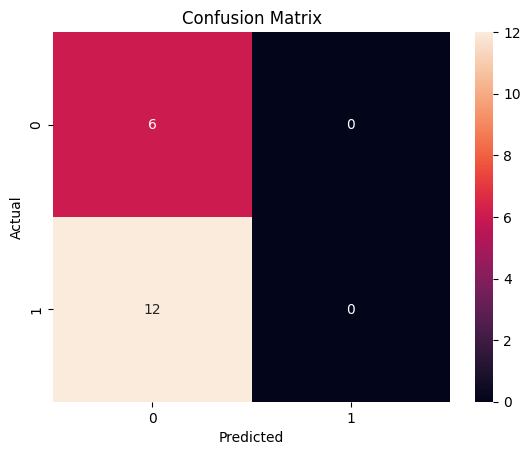

[I 2025-03-14 17:18:55,506] Trial 6 finished with value: 0.6954295635223389 and parameters: {'learning_rate': 1.0224269783068881e-05, 'dropout_rate': 0.25785511408360856, 'batch_size': 64, 'weight_decay': 0.00024788342912175843, 'lstm_units': 32}. Best is trial 2 with value: 0.6932938098907471.
Epoch 1/15


/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_73659/932603365.py:134: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("learning_rate", 1e-5, 1e-2)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_73659/932603365.py:135: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dr = trial.suggest_uniform("dropout_rate", 0.1, 0.5)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_73659/932603365.py:137: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  wd = trial.suggest_loguniform("weigh

4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step - accuracy: 0.3943 - loss: 0.7106 - val_accuracy: 0.3333 - val_loss: 0.6948
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.3773 - loss: 0.7113 - val_accuracy: 0.3333 - val_loss: 0.6951
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.3773 - loss: 0.7112 - val_accuracy: 0.3333 - val_loss: 0.6952
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.3773 - loss: 0.7112 - val_accuracy: 0.3333 - val_loss: 0.6952
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.3943 - loss: 0.7089 - val_accuracy: 0.3333 - val_loss: 0.6953
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.3773 - loss: 0.7111 - val_accuracy: 0.3333 - val_loss: 0.6953
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.3773 - loss: 0.7111 - val_accuracy: 0.3333 - val_loss: 0.6953
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.3943 - loss: 0.7081 - val_accuracy: 0.3333 - val_loss: 0.6954
Epoch 9/15
4/4 ━━━━━━━━━━━

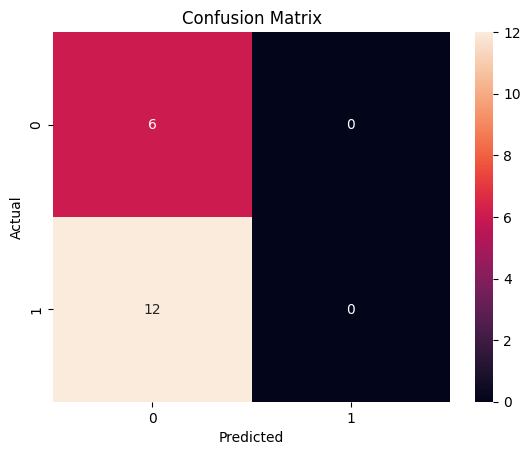

[I 2025-03-14 17:21:14,211] Trial 7 finished with value: 0.6967240571975708 and parameters: {'learning_rate': 0.0005719508462824964, 'dropout_rate': 0.49362869854552194, 'batch_size': 16, 'weight_decay': 6.111897163177906e-05, 'lstm_units': 64}. Best is trial 2 with value: 0.6932938098907471.
Epoch 1/15


/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_73659/932603365.py:134: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("learning_rate", 1e-5, 1e-2)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_73659/932603365.py:135: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dr = trial.suggest_uniform("dropout_rate", 0.1, 0.5)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_73659/932603365.py:137: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  wd = trial.suggest_loguniform("weigh

2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 4s/step - accuracy: 0.3654 - loss: 0.6943 - val_accuracy: 0.3333 - val_loss: 0.6938
Epoch 2/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 4s/step - accuracy: 0.3654 - loss: 0.6943 - val_accuracy: 0.3333 - val_loss: 0.6939
Epoch 3/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 5s/step - accuracy: 0.3654 - loss: 0.6942 - val_accuracy: 0.3333 - val_loss: 0.6940
Epoch 4/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 4s/step - accuracy: 0.3441 - loss: 0.6952 - val_accuracy: 0.3333 - val_loss: 0.6942
Epoch 5/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 4s/step - accuracy: 0.3441 - loss: 0.6952 - val_accuracy: 0.3333 - val_loss: 0.6943
Epoch 6/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 6s/step - accuracy: 0.3654 - loss: 0.6942 - val_accuracy: 0.3333 - val_loss: 0.6944
Epoch 7/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 4s/step - accuracy: 0.3654 - loss: 0.6942 - val_accuracy: 0.3333 - val_loss: 0.6945
Epoch 8/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 5s/step - accuracy: 0.3654 - loss: 0.6942 - val_accuracy: 0.3333 - val_loss: 0.6946
Epoch 9/15
2/2 ━━━━━━━━━━━

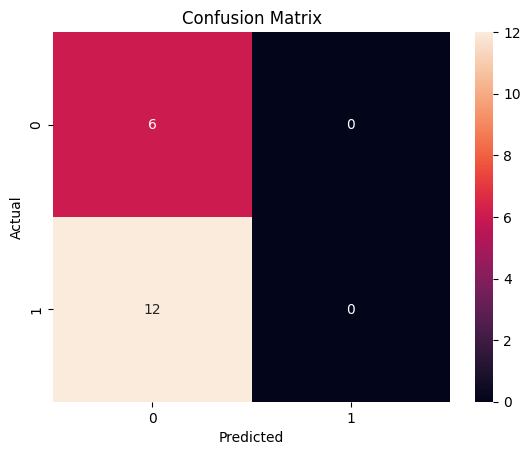

[I 2025-03-14 17:23:02,785] Trial 8 finished with value: 0.6953659653663635 and parameters: {'learning_rate': 3.439093771992073e-05, 'dropout_rate': 0.16626270598532372, 'batch_size': 32, 'weight_decay': 7.023848603399475e-05, 'lstm_units': 64}. Best is trial 2 with value: 0.6932938098907471.


/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_73659/932603365.py:134: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("learning_rate", 1e-5, 1e-2)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_73659/932603365.py:135: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dr = trial.suggest_uniform("dropout_rate", 0.1, 0.5)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_73659/932603365.py:137: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  wd = trial.suggest_loguniform("weigh

Epoch 1/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step - accuracy: 0.3443 - loss: 0.6958 - val_accuracy: 0.3333 - val_loss: 0.6941
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - accuracy: 0.3443 - loss: 0.6958 - val_accuracy: 0.3333 - val_loss: 0.6942
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step - accuracy: 0.3443 - loss: 0.6957 - val_accuracy: 0.3333 - val_loss: 0.6944
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step - accuracy: 0.3443 - loss: 0.6957 - val_accuracy: 0.3333 - val_loss: 0.6945
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step - accuracy: 0.3443 - loss: 0.6957 - val_accuracy: 0.3333 - val_loss: 0.6947
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.3443 - loss: 0.6955 - val_accuracy: 0.3333 - val_loss: 0.6948
Epoch 7/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - accuracy: 0.3443 - loss: 0.6956 - val_accuracy: 0.3333 - val_loss: 0.6949
Epoch 8/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - accuracy: 0.3443 - loss: 0.6956 - val_accuracy: 0.3333 - val_loss: 0.6951
Epoch 9/15
1/1

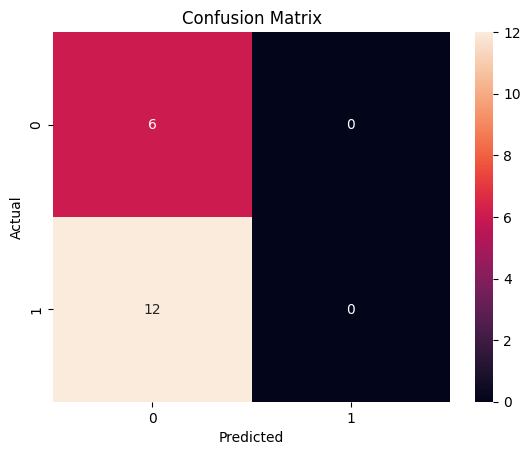

[I 2025-03-14 17:24:50,695] Trial 9 finished with value: 0.6959541440010071 and parameters: {'learning_rate': 0.0009271127723639728, 'dropout_rate': 0.1944383481011816, 'batch_size': 64, 'weight_decay': 9.623361568490028e-05, 'lstm_units': 64}. Best is trial 2 with value: 0.6932938098907471.


/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_73659/932603365.py:134: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("learning_rate", 1e-5, 1e-2)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_73659/932603365.py:135: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dr = trial.suggest_uniform("dropout_rate", 0.1, 0.5)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_73659/932603365.py:137: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  wd = trial.suggest_loguniform("weigh

Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.3773 - loss: 0.7147 - val_accuracy: 0.3333 - val_loss: 0.6999
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.3943 - loss: 0.7096 - val_accuracy: 0.3333 - val_loss: 0.6983
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.3773 - loss: 0.7102 - val_accuracy: 0.3333 - val_loss: 0.6969
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.3773 - loss: 0.7104 - val_accuracy: 0.3333 - val_loss: 0.6957
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.3943 - loss: 0.7088 - val_accuracy: 0.3333 - val_loss: 0.6947
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.3773 - loss: 0.7109 - val_accuracy: 0.3333 - val_loss: 0.6939
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.3943 - loss: 0.7069 - val_accuracy: 0.6667 - val_loss: 0.6929
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.4693 - loss: 0.6886 - val_accuracy: 0.3333 - val_loss: 0.7010
Epoch 9/15
4/4 

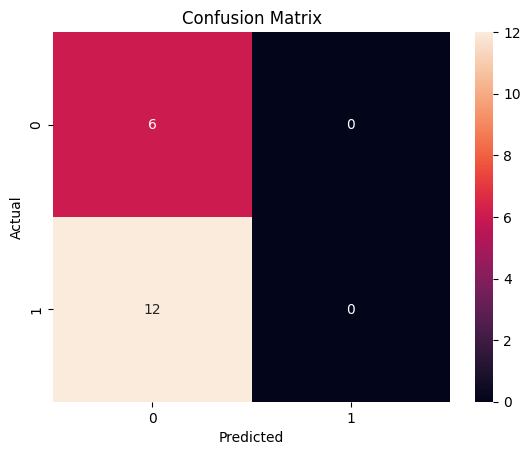

[I 2025-03-14 17:26:43,666] Trial 10 finished with value: 0.6954990029335022 and parameters: {'learning_rate': 0.009549720383294363, 'dropout_rate': 0.34671538944267943, 'batch_size': 16, 'weight_decay': 1.035421681897149e-05, 'lstm_units': 32}. Best is trial 2 with value: 0.6932938098907471.


/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_73659/932603365.py:134: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("learning_rate", 1e-5, 1e-2)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_73659/932603365.py:135: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dr = trial.suggest_uniform("dropout_rate", 0.1, 0.5)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_73659/932603365.py:137: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  wd = trial.suggest_loguniform("weigh

Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.3773 - loss: 0.7155 - val_accuracy: 0.3333 - val_loss: 0.6972
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.3773 - loss: 0.7155 - val_accuracy: 0.3333 - val_loss: 0.6972
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.3773 - loss: 0.7155 - val_accuracy: 0.3333 - val_loss: 0.6972
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.3773 - loss: 0.7151 - val_accuracy: 0.3333 - val_loss: 0.6972
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.3773 - loss: 0.7155 - val_accuracy: 0.3333 - val_loss: 0.6972
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.3773 - loss: 0.7155 - val_accuracy: 0.3333 - val_loss: 0.6972
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.3773 - loss: 0.7155 - val_accuracy: 0.3333 - val_loss: 0.6972
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.3773 - loss: 0.7155 - val_accuracy: 0.3333 - val_loss: 0.6972
Epoch 9/15
4/4 

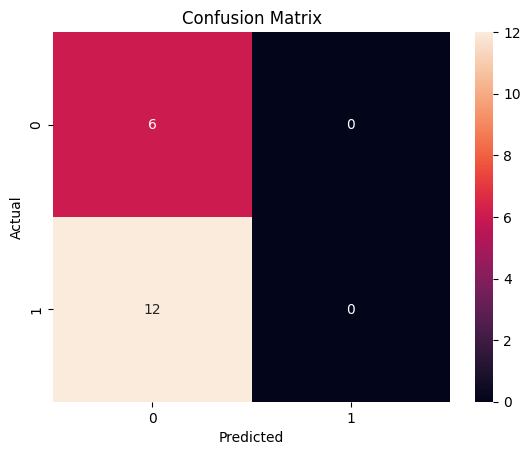

[I 2025-03-14 17:28:37,521] Trial 11 finished with value: 0.6972414255142212 and parameters: {'learning_rate': 1.0154695269498276e-05, 'dropout_rate': 0.10015200997687523, 'batch_size': 16, 'weight_decay': 0.0005020153047348123, 'lstm_units': 32}. Best is trial 2 with value: 0.6932938098907471.
Epoch 1/15


/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_73659/932603365.py:134: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("learning_rate", 1e-5, 1e-2)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_73659/932603365.py:135: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dr = trial.suggest_uniform("dropout_rate", 0.1, 0.5)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_73659/932603365.py:137: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  wd = trial.suggest_loguniform("weigh

4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.3773 - loss: 0.7144 - val_accuracy: 0.3333 - val_loss: 0.6935
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.3773 - loss: 0.7112 - val_accuracy: 0.3333 - val_loss: 0.6935
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.3773 - loss: 0.7112 - val_accuracy: 0.3333 - val_loss: 0.6935
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.3773 - loss: 0.7142 - val_accuracy: 0.3333 - val_loss: 0.6935
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.3773 - loss: 0.7112 - val_accuracy: 0.3333 - val_loss: 0.6935
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.3773 - loss: 0.7112 - val_accuracy: 0.3333 - val_loss: 0.6935
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.3773 - loss: 0.7142 - val_accuracy: 0.3333 - val_loss: 0.6935
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.3773 - loss: 0.7142 - val_accuracy: 0.3333 - val_loss: 0.6935
Epoch 9/15
4/4 ━━━━━━━━━━━

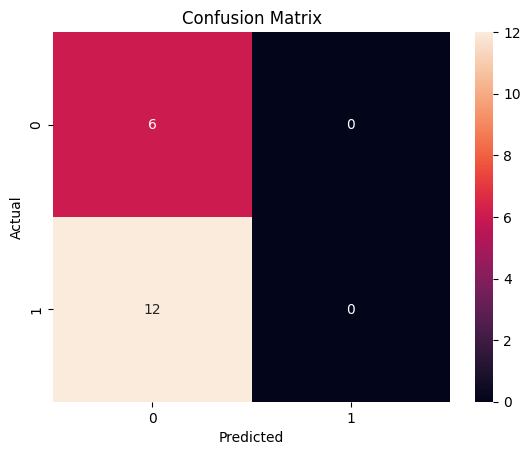

[I 2025-03-14 17:30:28,906] Trial 12 finished with value: 0.6935397386550903 and parameters: {'learning_rate': 5.669002902691315e-05, 'dropout_rate': 0.3204156760072671, 'batch_size': 16, 'weight_decay': 2.857591221102352e-05, 'lstm_units': 32}. Best is trial 2 with value: 0.6932938098907471.
Epoch 1/15


/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_73659/932603365.py:134: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("learning_rate", 1e-5, 1e-2)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_73659/932603365.py:135: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dr = trial.suggest_uniform("dropout_rate", 0.1, 0.5)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_73659/932603365.py:137: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  wd = trial.suggest_loguniform("weigh

4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.3773 - loss: 0.7113 - val_accuracy: 0.3333 - val_loss: 0.6935
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.3773 - loss: 0.7116 - val_accuracy: 0.3333 - val_loss: 0.6936
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.3773 - loss: 0.7116 - val_accuracy: 0.3333 - val_loss: 0.6936
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.3773 - loss: 0.7115 - val_accuracy: 0.3333 - val_loss: 0.6936
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.3773 - loss: 0.7115 - val_accuracy: 0.3333 - val_loss: 0.6936
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.3773 - loss: 0.7112 - val_accuracy: 0.3333 - val_loss: 0.6936
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.3773 - loss: 0.7114 - val_accuracy: 0.3333 - val_loss: 0.6936
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.3773 - loss: 0.7114 - val_accuracy: 0.3333 - val_loss: 0.6936
Epoch 9/15
4/4 ━━━━━━━━━━━

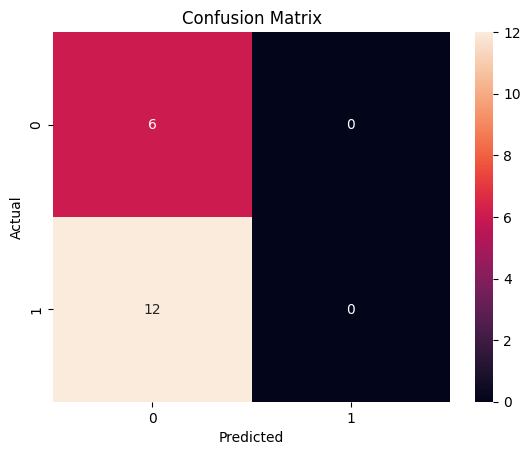

[I 2025-03-14 17:32:22,410] Trial 13 finished with value: 0.6936942934989929 and parameters: {'learning_rate': 0.000122033453263346, 'dropout_rate': 0.3212551054846983, 'batch_size': 16, 'weight_decay': 2.7116229485008754e-05, 'lstm_units': 32}. Best is trial 2 with value: 0.6932938098907471.


/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_73659/932603365.py:134: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("learning_rate", 1e-5, 1e-2)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_73659/932603365.py:135: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dr = trial.suggest_uniform("dropout_rate", 0.1, 0.5)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_73659/932603365.py:137: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  wd = trial.suggest_loguniform("weigh

Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.3773 - loss: 0.7111 - val_accuracy: 0.3333 - val_loss: 0.6933
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.3773 - loss: 0.7111 - val_accuracy: 0.3333 - val_loss: 0.6933
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.3943 - loss: 0.7108 - val_accuracy: 0.3333 - val_loss: 0.6933
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.3773 - loss: 0.7111 - val_accuracy: 0.3333 - val_loss: 0.6933
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.3773 - loss: 0.7111 - val_accuracy: 0.3333 - val_loss: 0.6933
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.3943 - loss: 0.7107 - val_accuracy: 0.3333 - val_loss: 0.6933
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.3773 - loss: 0.7111 - val_accuracy: 0.3333 - val_loss: 0.6933
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.3943 - loss: 0.7107 - val_accuracy: 0.3333 - val_loss: 0.6933
Epoch 9/15
4/4 

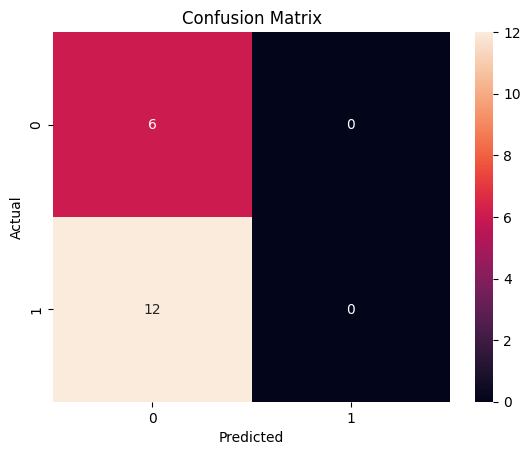

[I 2025-03-14 17:34:34,116] Trial 14 finished with value: 0.693352222442627 and parameters: {'learning_rate': 2.3815493930641388e-05, 'dropout_rate': 0.3829160796251679, 'batch_size': 16, 'weight_decay': 1.2357706221961137e-05, 'lstm_units': 64}. Best is trial 2 with value: 0.6932938098907471.


/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_73659/932603365.py:134: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("learning_rate", 1e-5, 1e-2)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_73659/932603365.py:135: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dr = trial.suggest_uniform("dropout_rate", 0.1, 0.5)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_73659/932603365.py:137: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  wd = trial.suggest_loguniform("weigh

Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.3943 - loss: 0.7110 - val_accuracy: 0.3333 - val_loss: 0.6933
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.3943 - loss: 0.7110 - val_accuracy: 0.3333 - val_loss: 0.6933
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.3943 - loss: 0.7109 - val_accuracy: 0.3333 - val_loss: 0.6933
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.3943 - loss: 0.7109 - val_accuracy: 0.3333 - val_loss: 0.6933
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.3943 - loss: 0.7109 - val_accuracy: 0.3333 - val_loss: 0.6933
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.3943 - loss: 0.7109 - val_accuracy: 0.3333 - val_loss: 0.6933
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.3773 - loss: 0.7111 - val_accuracy: 0.3333 - val_loss: 0.6933
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.3773 - loss: 0.7111 - val_accuracy: 0.3333 - val_loss: 0.6933
Epoch 9/15
4/4 

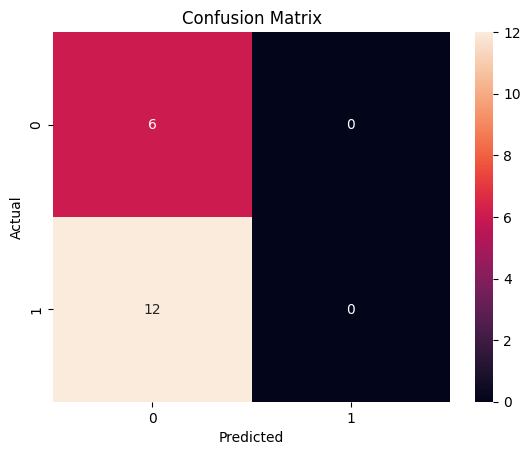

[I 2025-03-14 17:36:49,608] Trial 15 finished with value: 0.6933295130729675 and parameters: {'learning_rate': 2.2342066065213847e-05, 'dropout_rate': 0.3975738260717104, 'batch_size': 16, 'weight_decay': 1.0034347955162256e-05, 'lstm_units': 64}. Best is trial 2 with value: 0.6932938098907471.


/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_73659/932603365.py:134: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("learning_rate", 1e-5, 1e-2)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_73659/932603365.py:135: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dr = trial.suggest_uniform("dropout_rate", 0.1, 0.5)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_73659/932603365.py:137: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  wd = trial.suggest_loguniform("weigh

Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step - accuracy: 0.3773 - loss: 0.7189 - val_accuracy: 0.3333 - val_loss: 0.7004
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.3773 - loss: 0.7187 - val_accuracy: 0.3333 - val_loss: 0.7004
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.3773 - loss: 0.7185 - val_accuracy: 0.3333 - val_loss: 0.7004
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.3773 - loss: 0.7184 - val_accuracy: 0.3333 - val_loss: 0.7004
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.3773 - loss: 0.7182 - val_accuracy: 0.3333 - val_loss: 0.7003
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.3773 - loss: 0.7181 - val_accuracy: 0.3333 - val_loss: 0.7003
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.3773 - loss: 0.7180 - val_accuracy: 0.3333 - val_loss: 0.7003
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.3773 - loss: 0.7176 - val_accuracy: 0.3333 - val_loss: 0.7002
Epoch 9/15
4/4 

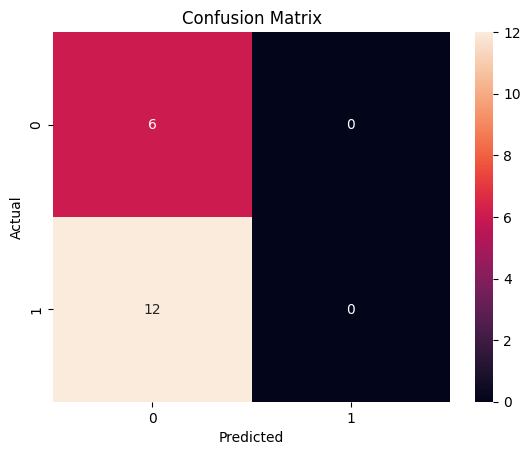

[I 2025-03-14 17:39:00,758] Trial 16 finished with value: 0.699886679649353 and parameters: {'learning_rate': 0.00013589015731826982, 'dropout_rate': 0.26325587536750633, 'batch_size': 16, 'weight_decay': 0.0009425226125013713, 'lstm_units': 64}. Best is trial 2 with value: 0.6932938098907471.
Epoch 1/15


/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_73659/932603365.py:134: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("learning_rate", 1e-5, 1e-2)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_73659/932603365.py:135: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dr = trial.suggest_uniform("dropout_rate", 0.1, 0.5)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_73659/932603365.py:137: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  wd = trial.suggest_loguniform("weigh

4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.3943 - loss: 0.7110 - val_accuracy: 0.3333 - val_loss: 0.6933
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.3773 - loss: 0.7111 - val_accuracy: 0.3333 - val_loss: 0.6933
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.3773 - loss: 0.7111 - val_accuracy: 0.3333 - val_loss: 0.6933
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.3773 - loss: 0.7111 - val_accuracy: 0.3333 - val_loss: 0.6934
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.3943 - loss: 0.7109 - val_accuracy: 0.3333 - val_loss: 0.6934
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.3943 - loss: 0.7109 - val_accuracy: 0.3333 - val_loss: 0.6934
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.3943 - loss: 0.7109 - val_accuracy: 0.3333 - val_loss: 0.6934
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.3773 - loss: 0.7111 - val_accuracy: 0.3333 - val_loss: 0.6934
Epoch 9/15
4/4 ━━━━━━━━━━━

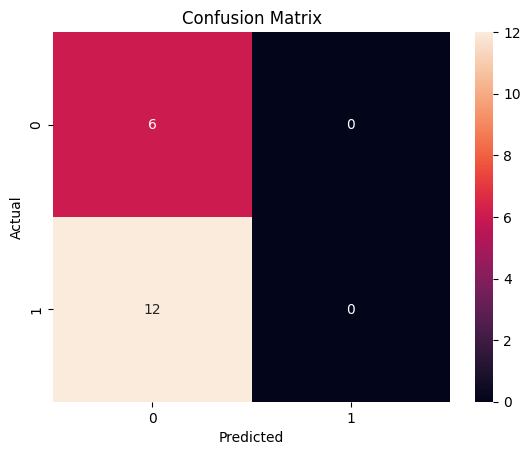

[I 2025-03-14 17:41:13,224] Trial 17 finished with value: 0.6933761239051819 and parameters: {'learning_rate': 1.8187770019598696e-05, 'dropout_rate': 0.3970533600683253, 'batch_size': 16, 'weight_decay': 1.9509491182914904e-05, 'lstm_units': 64}. Best is trial 2 with value: 0.6932938098907471.


/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_73659/932603365.py:134: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("learning_rate", 1e-5, 1e-2)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_73659/932603365.py:135: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dr = trial.suggest_uniform("dropout_rate", 0.1, 0.5)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_73659/932603365.py:137: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  wd = trial.suggest_loguniform("weigh

Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.3773 - loss: 0.7113 - val_accuracy: 0.3333 - val_loss: 0.6936
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.3773 - loss: 0.7113 - val_accuracy: 0.3333 - val_loss: 0.6936
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.3943 - loss: 0.7102 - val_accuracy: 0.3333 - val_loss: 0.6937
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.3773 - loss: 0.7112 - val_accuracy: 0.3333 - val_loss: 0.6937
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.3943 - loss: 0.7101 - val_accuracy: 0.3333 - val_loss: 0.6937
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.3943 - loss: 0.7101 - val_accuracy: 0.3333 - val_loss: 0.6937
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.3943 - loss: 0.7100 - val_accuracy: 0.3333 - val_loss: 0.6937
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.3773 - loss: 0.7112 - val_accuracy: 0.3333 - val_loss: 0.6937
Epoch 9/15
4/4 

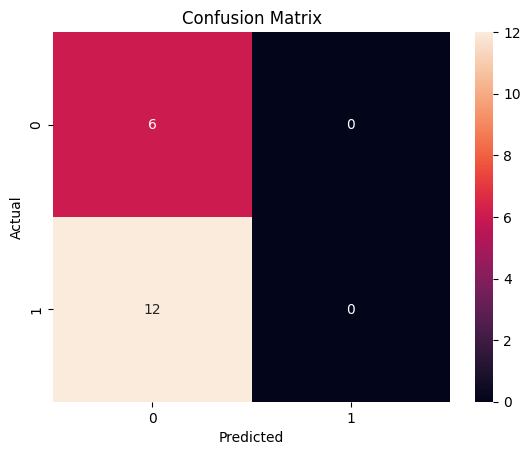

[I 2025-03-14 17:43:45,364] Trial 18 finished with value: 0.6938313841819763 and parameters: {'learning_rate': 0.00012351360197289496, 'dropout_rate': 0.2662771785534941, 'batch_size': 16, 'weight_decay': 3.589011943936738e-05, 'lstm_units': 64}. Best is trial 2 with value: 0.6932938098907471.


/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_73659/932603365.py:134: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("learning_rate", 1e-5, 1e-2)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_73659/932603365.py:135: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dr = trial.suggest_uniform("dropout_rate", 0.1, 0.5)
/var/folders/7g/xvz8wfd9477_ywln21gwjvdr0000gn/T/ipykernel_73659/932603365.py:137: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  wd = trial.suggest_loguniform("weigh

Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 13s 3s/step - accuracy: 0.3943 - loss: 0.7101 - val_accuracy: 0.3333 - val_loss: 0.6933
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.3943 - loss: 0.7101 - val_accuracy: 0.3333 - val_loss: 0.6933
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.3773 - loss: 0.7111 - val_accuracy: 0.3333 - val_loss: 0.6933
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.3943 - loss: 0.7100 - val_accuracy: 0.3333 - val_loss: 0.6933
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.3943 - loss: 0.7100 - val_accuracy: 0.3333 - val_loss: 0.6933
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.3943 - loss: 0.7100 - val_accuracy: 0.3333 - val_loss: 0.6933
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.3943 - loss: 0.7100 - val_accuracy: 0.3333 - val_loss: 0.6933
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.3943 - loss: 0.7100 - val_accuracy: 0.3333 - val_loss: 0.6933
Epoch 9/15
4/4

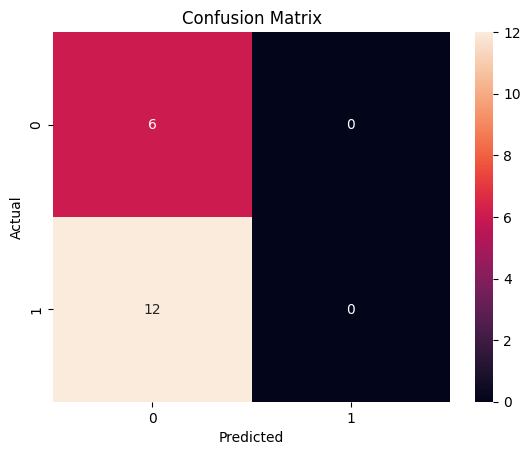

[I 2025-03-14 17:46:03,346] Trial 19 finished with value: 0.6933462619781494 and parameters: {'learning_rate': 2.1464989247495867e-05, 'dropout_rate': 0.36582840692456553, 'batch_size': 16, 'weight_decay': 1.4839246544917367e-05, 'lstm_units': 64}. Best is trial 2 with value: 0.6932938098907471.
Best hyperparameters:
{'learning_rate': 1.3203437491576292e-05, 'dropout_rate': 0.11425257950848407, 'batch_size': 16, 'weight_decay': 1.07490863331669e-05, 'lstm_units': 64}
Best Test Accuracy: 0.3333333333333333


In [ ]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Masking, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import optuna
import random
import tensorflow as tf


SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


epochs = 15  


input_dir = "issues-cleanedData"  

sequences = []
labels = []

issue_state_categories = set()
for filename in os.listdir(input_dir):
    if filename.endswith(".csv"):
        file_path = os.path.join(input_dir, filename)
        try:
            df = pd.read_csv(file_path)
        except Exception as e:
            print(f"Error reading {filename}: {e}")
            continue
        if 'type' in df.columns:
            df = df[df['type'] != 'comment']
        if 'issue_state' in df.columns:
            unique_states = df['issue_state'].dropna().unique()
            issue_state_categories.update(unique_states)
issue_state_categories = sorted(list(issue_state_categories))

label_map = {"graduated": 1, "retired": 0}

for filename in os.listdir(input_dir):
    if filename.endswith(".csv"):
        file_path = os.path.join(input_dir, filename)
        try:
            df = pd.read_csv(file_path)
        except Exception as e:
            print(f"Error reading {filename}: {e}")
            continue
        if 'type' in df.columns:
            df = df[df['type'] != 'comment']
        if not all(col in df.columns for col in ['issue_state', 'days_elapsed', 'status']):
            print(f"Skipping {filename}: required columns missing.")
            continue
        repo_status = df['status'].iloc[0]
        repo_status = repo_status.lower() if isinstance(repo_status, str) else repo_status
        if repo_status not in label_map:
            print(f"Skipping {filename}: status value '{repo_status}' not in label_map.")
            continue
        issue_state_dummies = pd.get_dummies(df['issue_state']).astype(int)
        issue_state_dummies = issue_state_dummies.reindex(columns=issue_state_categories, fill_value=0)
        try:
            scaler = StandardScaler()
            days_elapsed_scaled = scaler.fit_transform(df[['days_elapsed']].astype(float))
            days_elapsed = pd.DataFrame(days_elapsed_scaled, columns=['days_elapsed'])
        except Exception as e:
            print(f"Error processing 'days_elapsed' in {filename}: {e}")
            continue
        features = pd.concat([issue_state_dummies, days_elapsed], axis=1)
        features = features.fillna(0)
        seq = features.values
        if seq.shape[0] == 0:
            print(f"Skipping {filename}: no valid rows after filtering.")
            continue
        sequences.append(seq)
        labels.append(label_map[repo_status])

if not sequences:
    sys.exit("Error: No valid sequences found. Check CSV files for required columns and valid status values.")


max_timesteps = max(seq.shape[0] for seq in sequences)
X = pad_sequences(sequences, maxlen=max_timesteps, dtype='float32', padding='post', value=-1.0)
y = np.array(labels)

print("Processed Data Summary:")
print("Number of sequences:", len(sequences))
print("Shape of padded sequences (X):", X.shape)
print("Labels (y):", y)

class_weights = compute_class_weight('balanced', classes=np.unique(y), y=y)
class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}


X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42, shuffle=True
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=2/3, stratify=y_temp, random_state=42, shuffle=True
)


def objective(trial):
    lr = trial.suggest_loguniform("learning_rate", 1e-5, 1e-2)
    dr = trial.suggest_uniform("dropout_rate", 0.1, 0.5)
    bs = trial.suggest_categorical("batch_size", [16, 32, 64])
    wd = trial.suggest_loguniform("weight_decay", 1e-5, 1e-3)
    units = trial.suggest_categorical("lstm_units", [64, 32])

    model = Sequential()
    model.add(Masking(mask_value=-1.0, input_shape=(max_timesteps, X.shape[2])))
    model.add(LSTM(units, dropout=dr, kernel_regularizer=l2(wd)))
    model.add(Flatten())
    model.add(Dense(1, activation='sigmoid', kernel_regularizer=l2(wd)))

    optimizer = Adam(learning_rate=lr)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

    history = model.fit(X_train, y_train,
                        epochs=epochs,
                        batch_size=bs,
                        validation_data=(X_val, y_val),
                        class_weight=class_weight_dict,
                        verbose=1)

    y_pred_prob = model.predict(X_test)
    y_pred = (y_pred_prob > 0.5).astype(int).reshape(-1)
    acc = np.mean(y_pred == y_test)
    cm = confusion_matrix(y_test, y_pred)
    print(f"Test Accuracy: {acc}")
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    trial.set_user_attr("test_acc", acc)

    return history.history['val_loss'][-1]

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=20, show_progress_bar=True)

print("Best hyperparameters:")
print(study.best_params)

best_trial = study.best_trial
best_acc = best_trial.user_attrs.get("test_acc", None)

print(f"Best Test Accuracy: {best_acc}")
